%%%%%%%%%%%%%%%%%%%%%%% CUSTOMER CHURN PREDICITON %%%%%%%%%%%%%%%%%%%%%%%%

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
from sklearn.preprocessing import LabelEncoder
import pickle

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df = df.drop(columns = ["customerID"])

In [8]:
# Numerical columns (int , float)
numeric_cols = ["tenure","MonthlyCharges","TotalCharges"]

In [9]:
# Looking the unique values in each categorical columns
for col in df.columns:
    if col not in numeric_cols:
        print(df[col].unique())
        print("-"*30)

['Female' 'Male']
------------------------------
[0 1]
------------------------------
['Yes' 'No']
------------------------------
['No' 'Yes']
------------------------------
['No' 'Yes']
------------------------------
['No phone service' 'No' 'Yes']
------------------------------
['DSL' 'Fiber optic' 'No']
------------------------------
['No' 'Yes' 'No internet service']
------------------------------
['Yes' 'No' 'No internet service']
------------------------------
['No' 'Yes' 'No internet service']
------------------------------
['No' 'Yes' 'No internet service']
------------------------------
['No' 'Yes' 'No internet service']
------------------------------
['No' 'Yes' 'No internet service']
------------------------------
['Month-to-month' 'One year' 'Two year']
------------------------------
['Yes' 'No']
------------------------------
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
------------------------------
['No' 'Yes']
--------------

In [10]:
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
# NO null values in the Dataset

In [12]:
len(df[df.TotalCharges == ''])

0

In [13]:
df['TotalCharges'] = df["TotalCharges"].replace({' ': '0.0'})

In [14]:
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [15]:
sns.set_style("darkgrid")

In [16]:
def plot_hist(column_name):
    # plotting the Histogram for each Numerical columns 
    sns.histplot(df[column_name] , kde = True)
    plt.title(f"Distribution of the {column_name} Column")
    #Finding the mean and Median of the columns
    mean_col = df[column_name].mean()
    median_col = df[column_name].median()
    # plotting the verdical line for mean and median
    plt.axvline(mean_col , color = 'red', linestyle = 'solid', label= 'MEAN')
    plt.axvline(median_col , color = 'blue', linestyle = '--', label = "MEDIAN")

    plt.legend()
    plt.show()

    

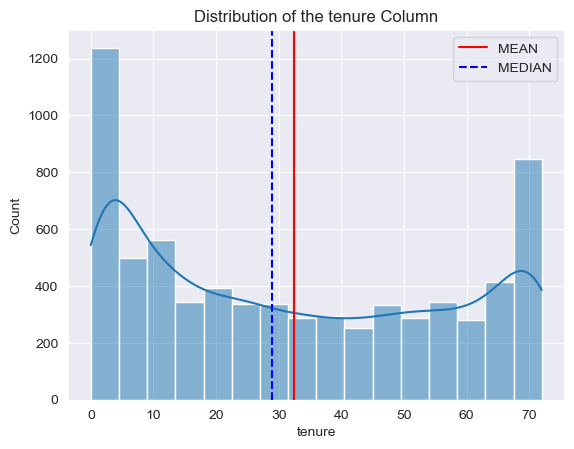

In [17]:
plot_hist("tenure")

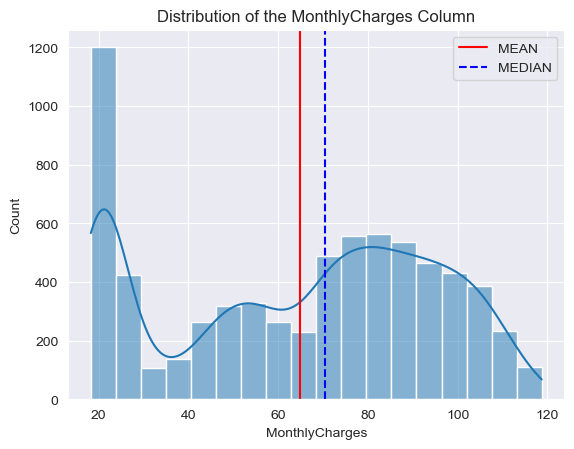

In [18]:
plot_hist("MonthlyCharges")

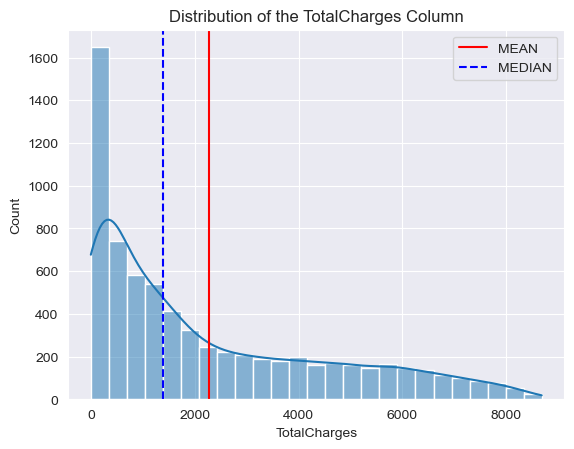

In [19]:
plot_hist("TotalCharges")

In [20]:
def plot_boxplot(column_name):
    # plotting the Histogram for each Numerical columns 
    sns.boxplot(df[column_name] )
    plt.title(f"Box plot of the {column_name} Column")
    plt.show()

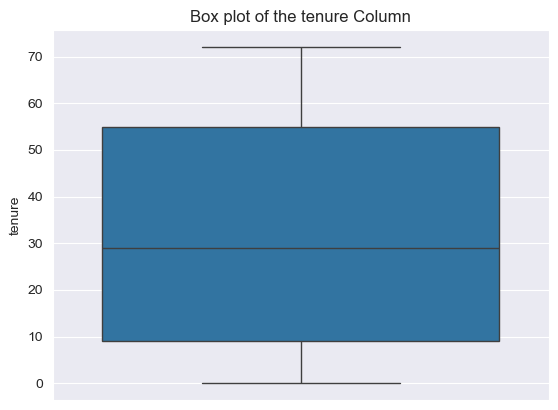

In [21]:
plot_boxplot("tenure")

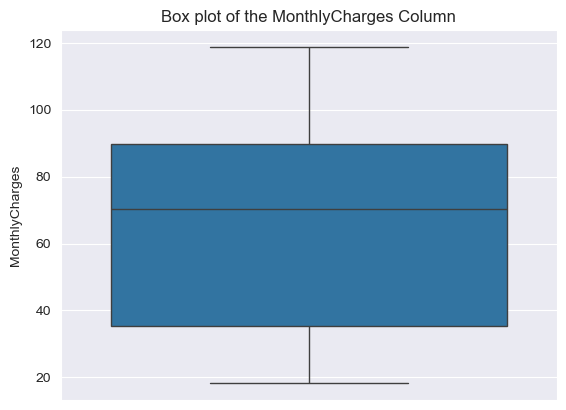

In [22]:
plot_boxplot("MonthlyCharges")

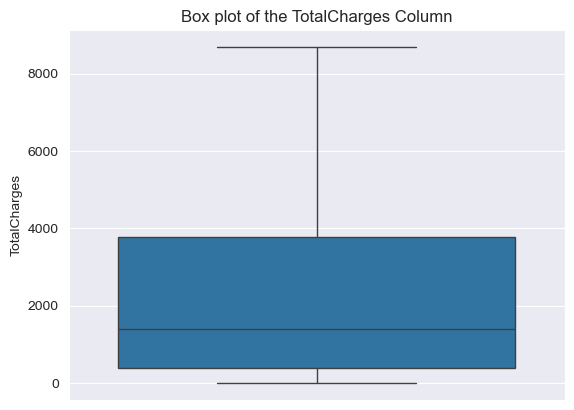

In [23]:
plot_boxplot("TotalCharges")

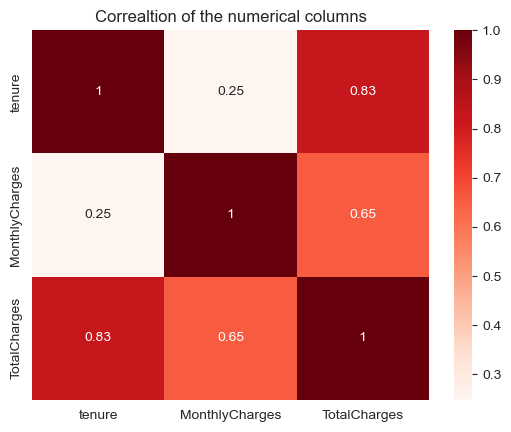

In [24]:
# Correlation co-efficient
sns.heatmap(df[numeric_cols].corr(), annot = True , cmap = 'Reds')
plt.title("Correaltion of the numerical columns")
plt.show()

In [25]:
categorical_cols = df.select_dtypes(include = "object").columns.tolist()

In [26]:
print(categorical_cols)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


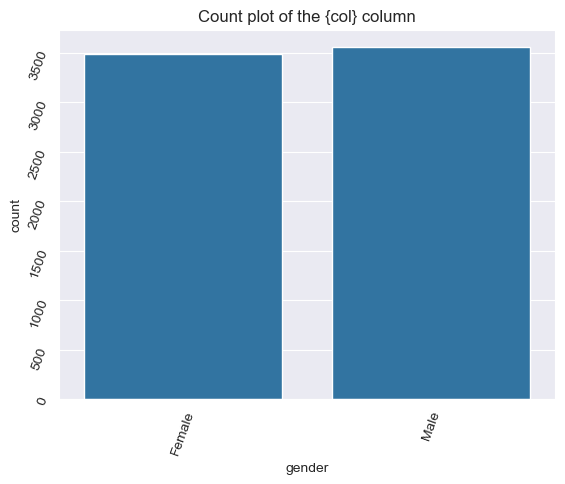

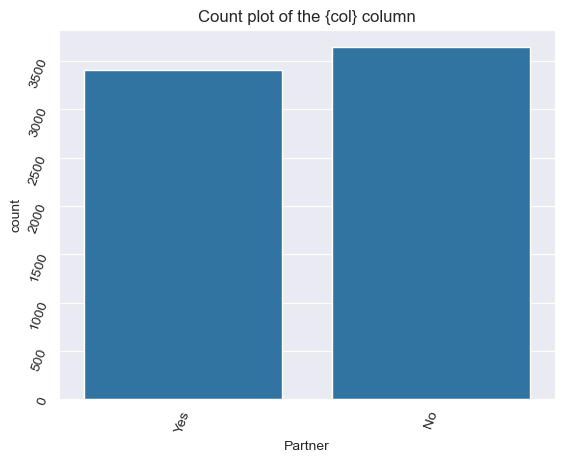

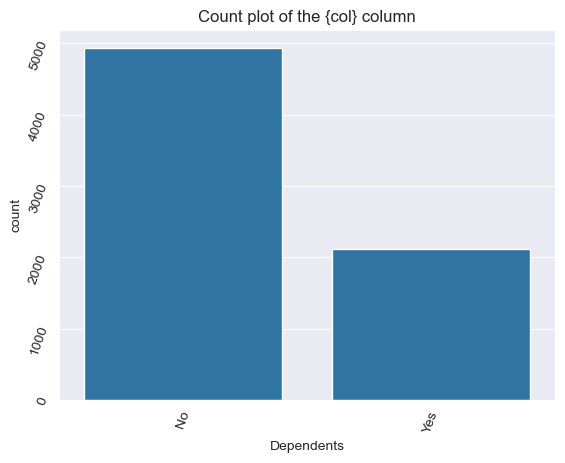

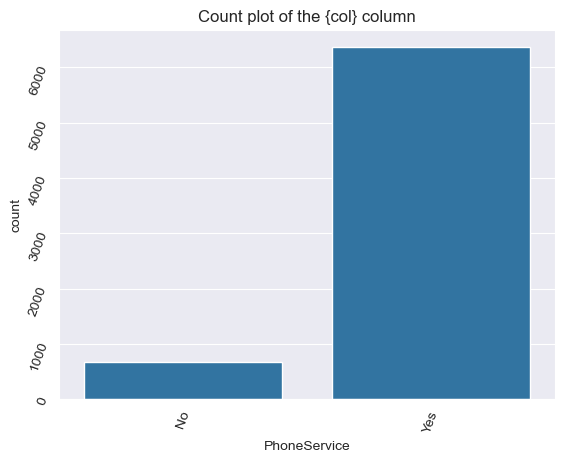

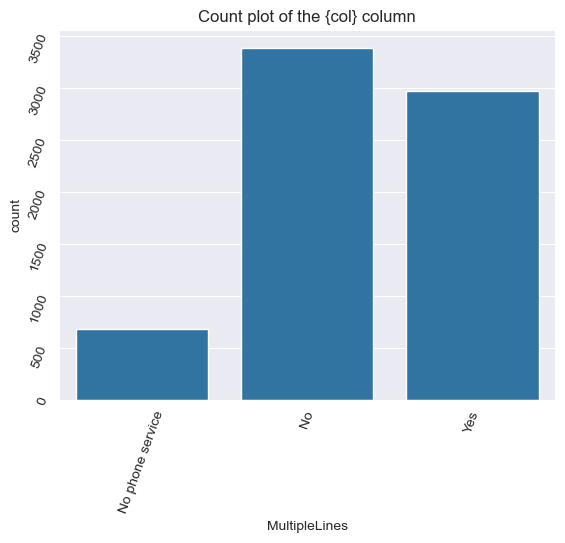

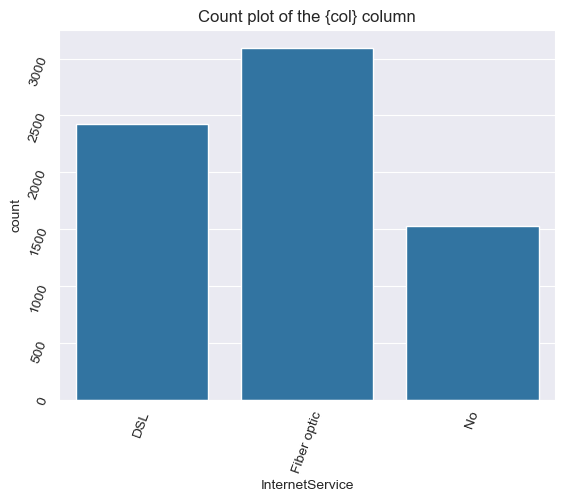

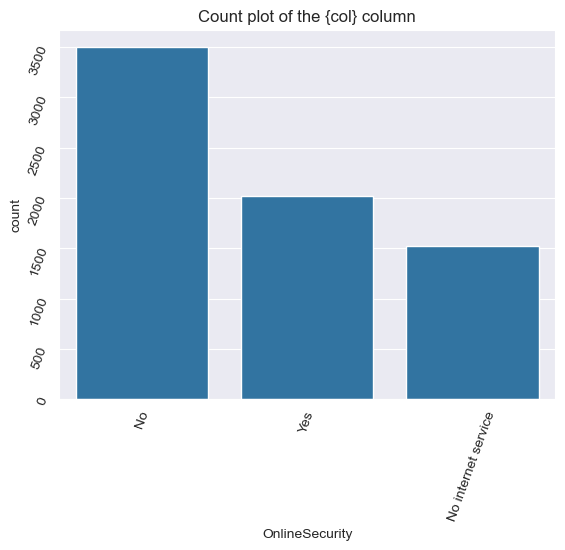

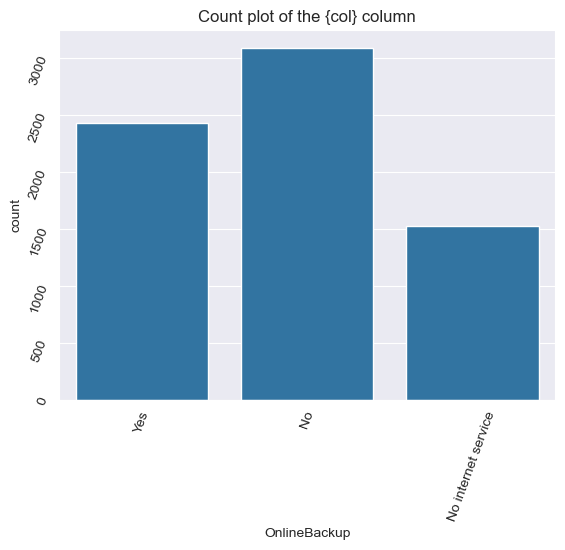

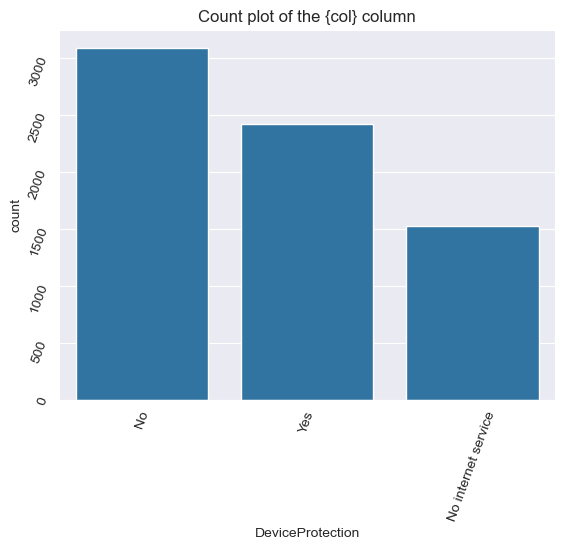

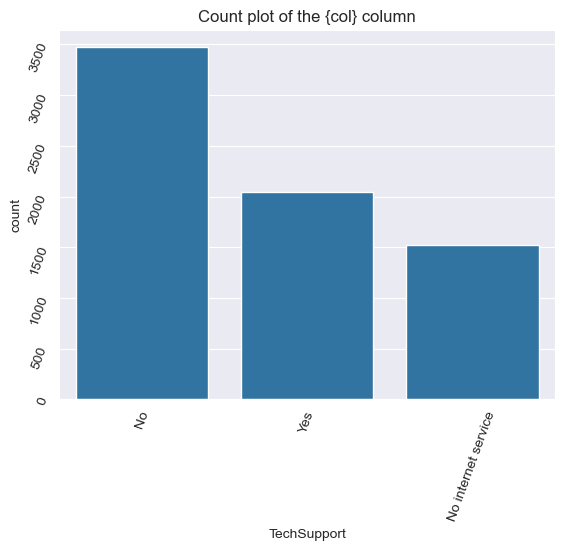

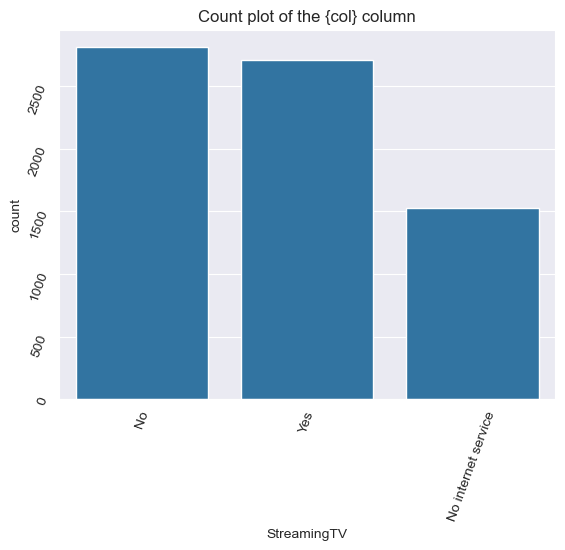

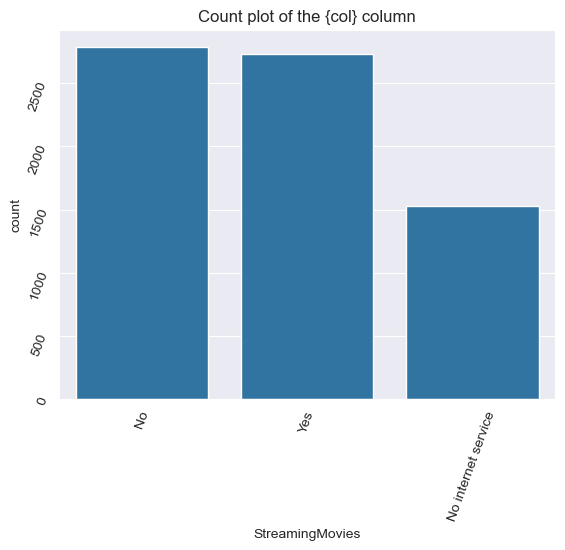

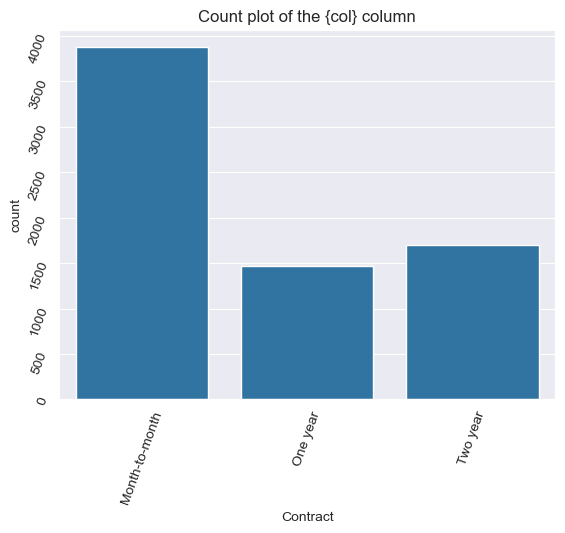

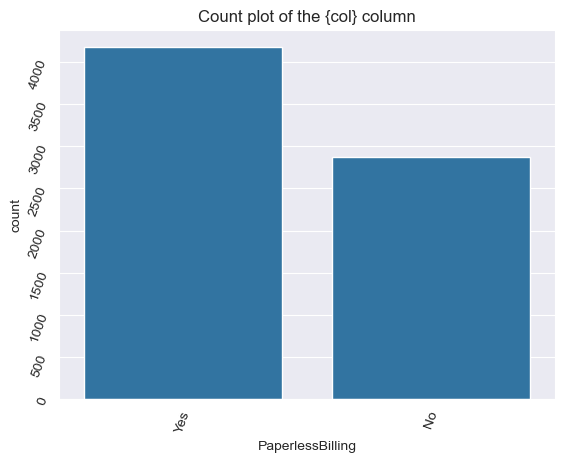

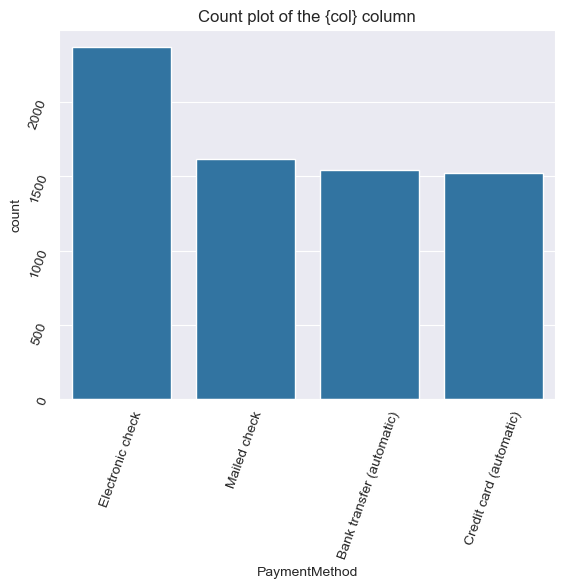

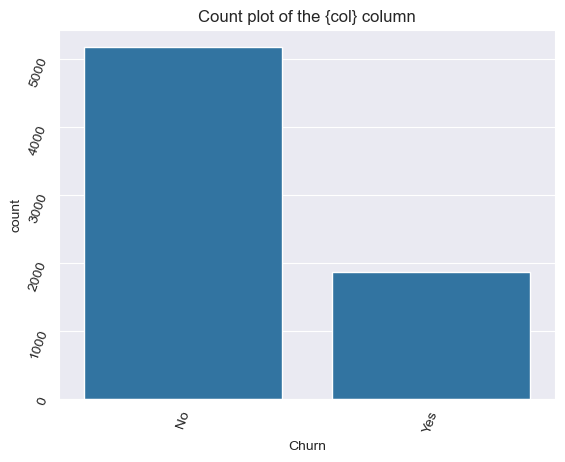

In [27]:
for col in categorical_cols:
    sns.countplot(x= df[col])
    plt.title("Count plot of the {col} column")
    plt.xticks(rotation = 70)
    plt.yticks(rotation = 70)
    plt.show()

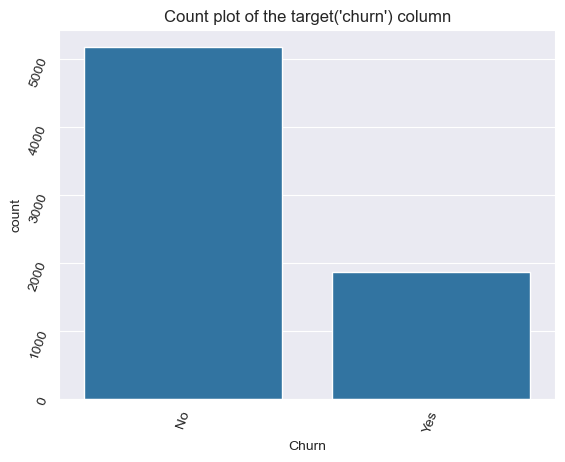

In [28]:
sns.countplot(x= df["Churn"])
plt.title("Count plot of the target('churn') column")
plt.xticks(rotation = 70)
plt.yticks(rotation = 70)
plt.show()

In [29]:
df.Churn.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [30]:
df['Churn'] = df['Churn'].replace({'Yes':1,'No':0})
'''
churn_code = {"Yes": 1 , "No": 0}
df["Churn"] = df['Churn].map(churn_code)
'''

C:\Users\tanu\AppData\Local\Temp\ipykernel_1352\293871204.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({'Yes':1,'No':0})


'\nchurn_code = {"Yes": 1 , "No": 0}\ndf["Churn"] = df[\'Churn].map(churn_code)\n'

In [31]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1


In [32]:
encoders = {}
for col in categorical_cols:
    label_encoder = LabelEncoder()
    df[col] = label_encoder.fit_transform(df[col])
    encoders[col] = label_encoder
    

In [33]:
with open("encoder.pkl" , 'wb') as f:
    pickle.dump(encoders , f)

In [34]:
print(encoders)

{'gender': LabelEncoder(), 'Partner': LabelEncoder(), 'Dependents': LabelEncoder(), 'PhoneService': LabelEncoder(), 'MultipleLines': LabelEncoder(), 'InternetService': LabelEncoder(), 'OnlineSecurity': LabelEncoder(), 'OnlineBackup': LabelEncoder(), 'DeviceProtection': LabelEncoder(), 'TechSupport': LabelEncoder(), 'StreamingTV': LabelEncoder(), 'StreamingMovies': LabelEncoder(), 'Contract': LabelEncoder(), 'PaperlessBilling': LabelEncoder(), 'PaymentMethod': LabelEncoder(), 'Churn': LabelEncoder()}


In [35]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50,0
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90,0
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45,0
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60,1


In [36]:
inputs = df.drop(columns = ['Churn'])
target = df.Churn

In [37]:
x_train, x_test , train_target ,test_target = train_test_split(inputs,target , test_size = 0.2 ,random_state = 42)

In [38]:
x_train.shape

(5634, 19)

In [39]:
x_test.shape

(1409, 19)

In [40]:
# sythetic minority oversampling technique (SMOTE)

In [41]:
df.Churn.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [42]:
smote = SMOTE(random_state = 42)
x_train_smote , train_target_smote = smote.fit_resample(x_train, train_target)


In [43]:
x_train_smote.shape

(8276, 19)

In [44]:
train_target_smote.value_counts()

Churn
0    4138
1    4138
Name: count, dtype: int64

In [45]:
inputs.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [46]:
from sklearn.linear_model import LogisticRegression

In [47]:
models ={
    'LogesticRegression': LogisticRegression(),
    'Decision tree': DecisionTreeClassifier(random_state = 42),
    'Random forest': RandomForestClassifier(random_state = 42),
    'xgboost': XGBClassifier(random_state = 42)

    
}

In [48]:
import warnings
warnings.filterwarnings("ignore")

In [49]:
cv_score ={}
for name , model in models.items():
    print(f"training {name} model ")
    score = cross_val_score(model ,x_train ,train_target, cv = 5 , scoring = 'accuracy')
    cv_score[name] = score
    print(f"{name} Cross validation accuracy score {np.mean(score)}")
    print("-"*50)

training LogesticRegression model 
LogesticRegression Cross validation accuracy score 0.7958836944307416
--------------------------------------------------
training Decision tree model 
Decision tree Cross validation accuracy score 0.7302087782367561
--------------------------------------------------
training Random forest model 
Random forest Cross validation accuracy score 0.7900236563850963
--------------------------------------------------
training xgboost model 
xgboost Cross validation accuracy score 0.7720969706903535
--------------------------------------------------


In [50]:
model = RandomForestClassifier(random_state = 42).fit(x_train, train_target)
train_preds = model.predict(x_train)
test_preds = model.predict(x_test)
print("Accuacy Score: ",accuracy_score(test_target, test_preds))
print("confusion Matrix : ", confusion_matrix(test_target , test_preds))
print('Classification Report: ', classification_report(test_target ,test_preds)) 

Accuacy Score:  0.794889992902768
confusion Matrix :  [[944  92]
 [197 176]]
Classification Report:                precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [51]:
model_data = {'model':model , "feature_name": inputs.columns.tolist()}

In [52]:
with open("customerchurn.pkl", 'wb') as f:
    pickle.dump(model_data , f)

In [53]:
with open("customerchurn.pkl", 'rb') as f:
    pickle.load(f)

In [54]:
loaded_model = model_data['model']
feature_name = model_data["feature_name"]

In [55]:
with open("encoder.pkl",'rb') as f:
    pickle.load(f)

In [56]:
df


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3,84.80,1990.50,0
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1,103.20,7362.90,0
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2,29.60,346.45,0
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3,74.40,306.60,1


In [58]:
customer_input = {
    "gender": "Female",
    "SeniorCitizen":0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 1,
    "PhoneService": "No",
    "MultipleLines": "No phone service",
    "InternetService": "DSL",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 29.85,
    "TotalCharges": 29.85,
    "Churn": "No"
}

In [59]:
customer_input_df = pd.DataFrame([customer_input])


In [60]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder(),
 'Churn': LabelEncoder()}

In [61]:
categorical_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [62]:
customer_input_df


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


In [63]:
customer_df = customer_input_df[categorical_cols]

In [ ]:
for column , encoder in encoders.items():
    customer_df[column] = encoder.transform(customer_df[column])
    


In [ ]:
preds = loaded_model.predict(customer_input_df)
print(preds)

In [ ]:
if preds[0] == 1:
    print("Churn")
else:
    print("Not Churn")